## 데이터 로드

In [1]:
import pandas as pd
df = pd.read_csv('data/SaaS-Sales.csv')
display(df.head())
rfm = pd.read_csv('data/Result 2025-12-25 18-27-32.csv')
discount = pd.read_csv('data/Result 2025-12-25 03-58-18.csv')
cohort = pd.read_csv('data/Result 2025-12-25 03-58-51.csv')
display(rfm.head())
display(discount.head())
display(cohort.head())

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
0,1,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136
1,2,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820
2,3,AMER-2022-138688,6/13/2022,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714
3,4,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310
4,5,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164


,customer,rfm_score,last_order_date,order_count,total_profit,margin_pct,rfm_total
0,Allstate,525,2023-12-30,61,-2796.2935,-7.00,525
1,Bosch,225,2023-12-09,60,-1823.7794,-7.17,225
2,Nissan Motor,545,2023-12-30,40,-1585.1886,-7.00,545
3,Costco Wholesale,545,2023-12-30,37,-1354.8547,-6.22,545
4,Walgreens,355,2023-12-17,33,-740.6747,-5.14,355


,discount_bucket,avg_margin_pct,order_count,total_profit
0,0% (No Discount),34.02,4798,320987.6032
1,10-20%,17.48,3709,91756.2975
2,0-10%,15.58,94,9029.1770
3,20%+ (High Discount),-78.45,1393,-135376.0560


,first_month,order_month,customers,retention_rate
0,2020-01-01 00:00:00+09,2020-01-01 00:00:00+09,27,100.000000
1,2020-01-01 00:00:00+09,2020-02-01 00:00:00+09,9,33.333333
2,2020-01-01 00:00:00+09,2020-03-01 00:00:00+09,11,40.740741
3,2020-01-01 00:00:00+09,2020-04-01 00:00:00+09,11,40.740741
4,2020-01-01 00:00:00+09,2020-05-01 00:00:00+09,14,51.851852


## 데이터 확인

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   object 
 2   Order Date    9994 non-null   object 
 3   Date Key      9994 non-null   int64  
 4   Contact Name  9994 non-null   object 
 5   Country       9994 non-null   object 
 6   City          9994 non-null   object 
 7   Region        9994 non-null   object 
 8   Subregion     9994 non-null   object 
 9   Customer      9994 non-null   object 
 10  Customer ID   9994 non-null   int64  
 11  Industry      9994 non-null   object 
 12  Segment       9994 non-null   object 
 13  Product       9994 non-null   object 
 14  License       9994 non-null   object 
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994 non-null   float64
 18  Profit        9994 non-null 

In [3]:
df.isnull().sum()

Row ID          0
Order ID        0
Order Date      0
Date Key        0
Contact Name    0
Country         0
City            0
Region          0
Subregion       0
Customer        0
Customer ID     0
Industry        0
Segment         0
Product         0
License         0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [4]:
df.isna().sum()

Row ID          0
Order ID        0
Order Date      0
Date Key        0
Contact Name    0
Country         0
City            0
Region          0
Subregion       0
Customer        0
Customer ID     0
Industry        0
Segment         0
Product         0
License         0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [5]:
dup = df[df.duplicated(['Row ID'], keep = False)]
dup.count()

Row ID          0
Order ID        0
Order Date      0
Date Key        0
Contact Name    0
Country         0
City            0
Region          0
Subregion       0
Customer        0
Customer ID     0
Industry        0
Segment         0
Product         0
License         0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

<Axes: >

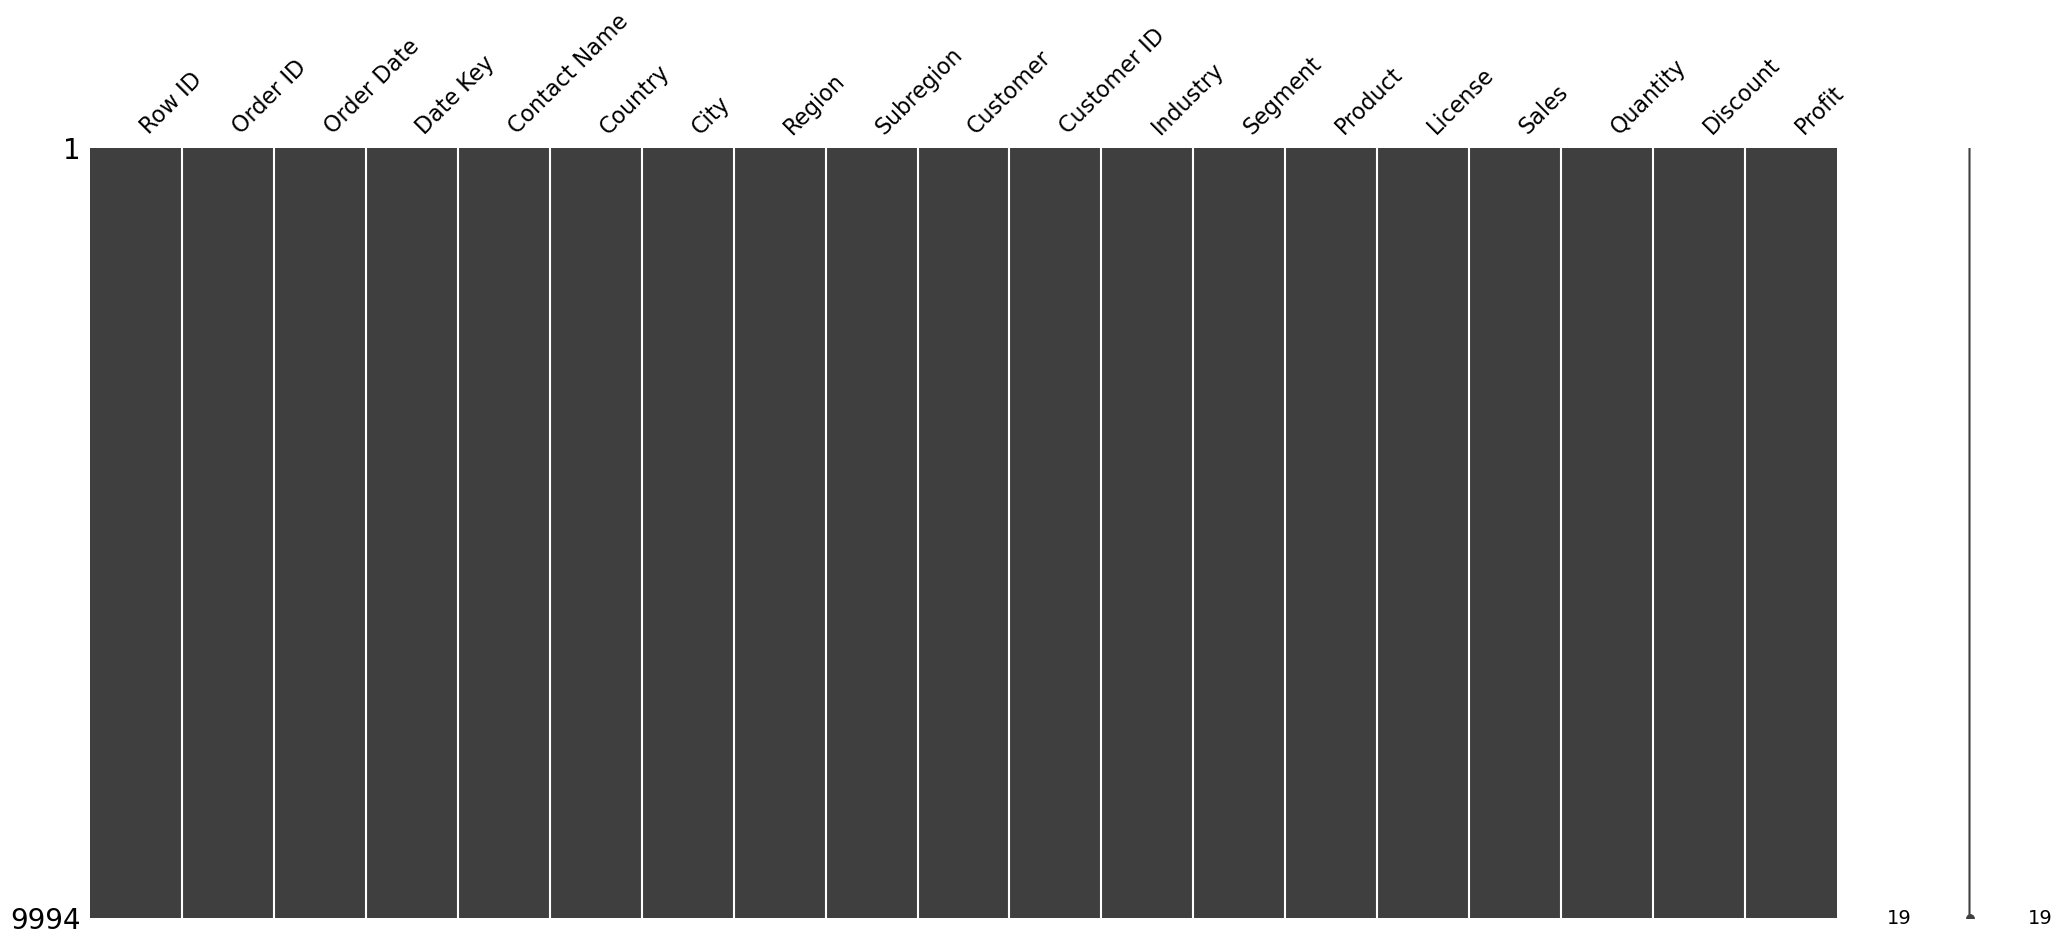

In [6]:
import missingno as msno
msno.matrix(df)

In [7]:
df.nunique()

Row ID          9994
Order ID        5009
Order Date      1237
Date Key        1237
Contact Name     793
Country           48
City             262
Region             3
Subregion         12
Customer          99
Customer ID       99
Industry          10
Segment            3
Product           14
License         9994
Sales           5825
Quantity          14
Discount          12
Profit          7287
dtype: int64

## 데이터 시각화

In [8]:
# 매출 총계
labels = ['Sales','Profit','margin']
print("매출 총계 :",df['Sales'].sum())
print("순이익 총계 :", df['Profit'].sum())
print("마진율 :", (df['Profit'].sum()/df['Sales'].sum())*100)

매출 총계 : 2297200.8603000003
순이익 총계 : 286397.0217
마진율 : 12.467217240315604


<Axes: xlabel='discount_bucket', ylabel='total_profit'>

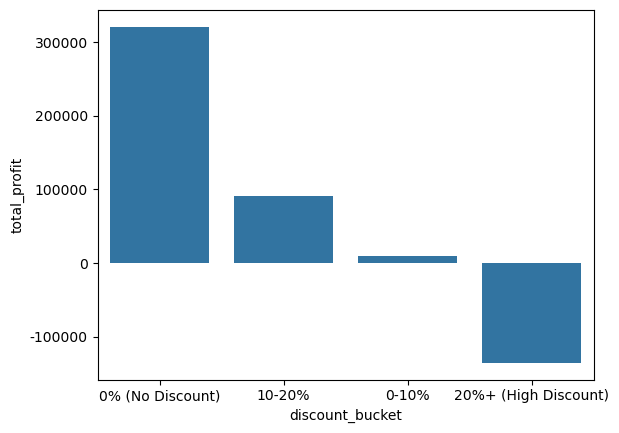

In [9]:
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
mpl.rcParams["axes.unicode_minus"] = False
sns.barplot(data = discount, x = 'discount_bucket', y = 'total_profit')

In [10]:
rfm_freq = pd.read_csv('data/Result 2025-12-25 19-43-01.csv')
rfm_freq.head()

,customer_id,customer,last_order_date,first_order_date,order_count,total_profit,total_sales,total_profit_margin_pct,avg_days_between_orders,recency_days
0,1093,Valero Energy,2023-12-16,2020-03-18,58,10308.6297,41220.4188,25.01,24,740
1,1021,Coca-Cola,2023-12-22,2020-02-28,38,9449.0246,28643.8040,32.99,37,734
2,1100,Trafigura Group,2023-12-24,2020-03-02,52,8867.8252,33447.1270,26.51,27,732
3,1067,Mondelez International,2023-12-29,2020-02-05,61,8577.6524,32993.0458,26.00,23,727
4,1060,Lowes,2023-12-24,2020-01-21,58,7937.4915,40360.1630,19.67,25,732


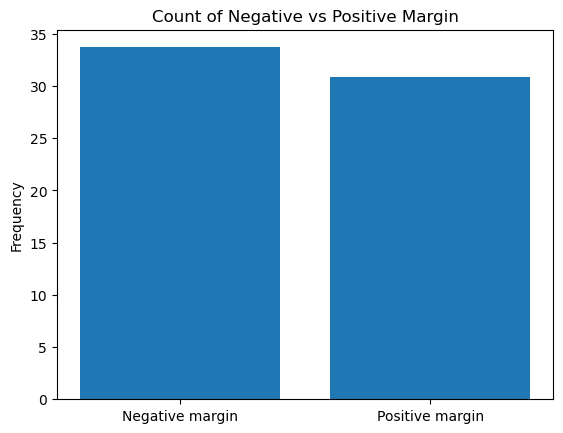

In [11]:
neg_margin_mean = rfm_freq.loc[rfm_freq["total_profit_margin_pct"] < 0, "avg_days_between_orders"].mean()
pos_margin_mean = rfm_freq.loc[rfm_freq["total_profit_margin_pct"] >= 0, "avg_days_between_orders"].mean()

x = ["Negative margin", "Positive margin"]
y = [neg_margin_mean, pos_margin_mean]

plt.bar(x, y)
plt.title("Count of Negative vs Positive Margin")
plt.ylabel("Frequency")
plt.show()

In [12]:
discount_freq = pd.read_csv('data/Result 2025-12-25 19-55-41.csv')
discount_freq.head()

,discount_bucket,avg_days_between_orders,intervals_count
0,0-10%,4.15,4784
1,10-20%,28.32,142
2,20-30%,5.44,3643
3,30%+,8.13,1385


<Axes: xlabel='discount_bucket', ylabel='avg_days_between_orders'>

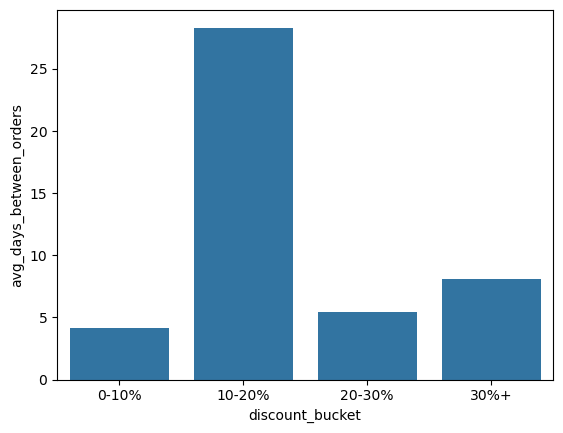

In [13]:
sns.barplot(data = discount_freq, x = 'discount_bucket', y = 'avg_days_between_orders')

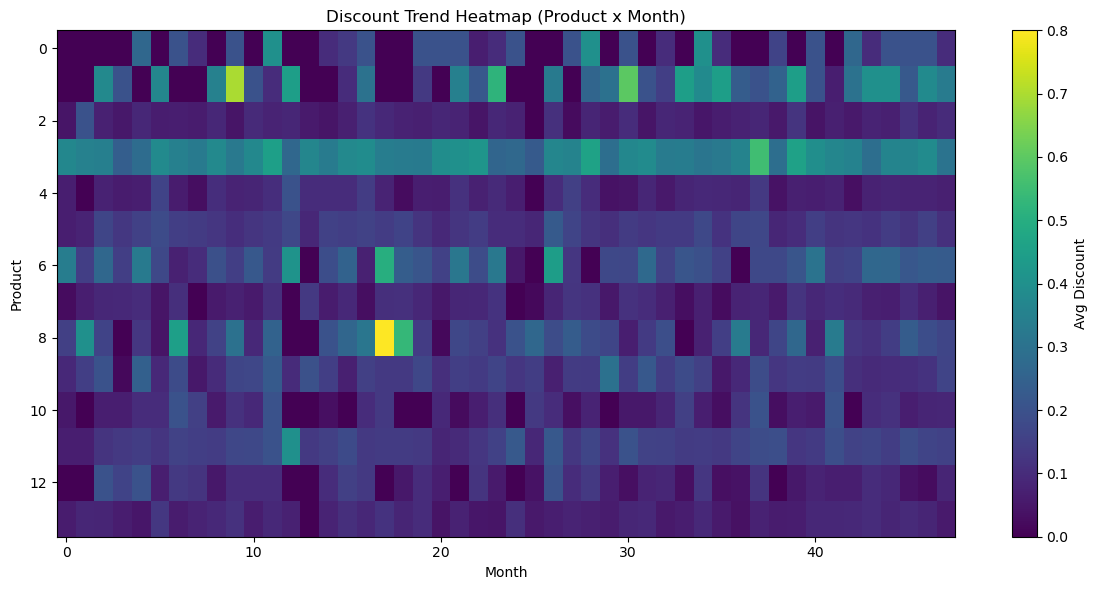

In [14]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["month"] = df["Order Date"].dt.to_period("M").dt.to_timestamp()

pivot = (df.groupby(["Product","month"])["Discount"].mean()
           .reset_index()
           .pivot(index="Product", columns="month", values="Discount")
           .fillna(0))

plt.figure(figsize=(12,6))
plt.imshow(pivot.values, aspect="auto")
plt.title("Discount Trend Heatmap (Product x Month)")
plt.xlabel("Month")
plt.ylabel("Product")
plt.colorbar(label="Avg Discount")
plt.tight_layout()
plt.show()

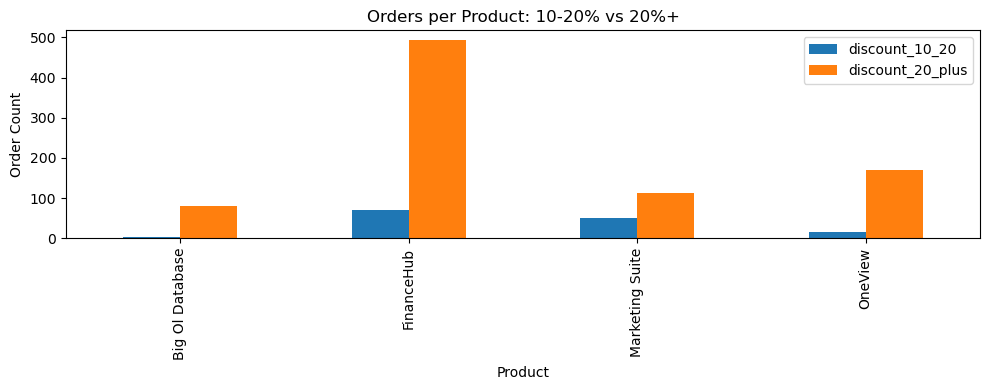

In [15]:
a = df[(df["Discount"] >= 0.10) & (df["Discount"] < 0.20)]
a = a.groupby("Product")["Order ID"].nunique()

b = df[df["Discount"] >= 0.20]
b = b.groupby("Product")["Order ID"].nunique()

result = pd.concat([a, b], axis=1)
result.columns = ["discount_10_20", "discount_20_plus"]
result = result.fillna(0)

result = result[result["discount_10_20"] > 0]
plot_df = result

plot_df.plot(kind="bar", figsize=(10,4))
plt.title("Orders per Product: 10-20% vs 20%+")
plt.ylabel("Order Count")
plt.tight_layout()
plt.show()

In [17]:
products = ["FinanceHub", "OneView", "Marketing Suite", "Big Ol Database"]

# 날짜 준비
df["Order Date"] = pd.to_datetime(df["Order Date"])

# 분석 기준일(데이터에서 가장 마지막 날짜)
today = df["Order Date"].max()

# 최근 3개월 시작일
start_3m = today - pd.DateOffset(months=3)

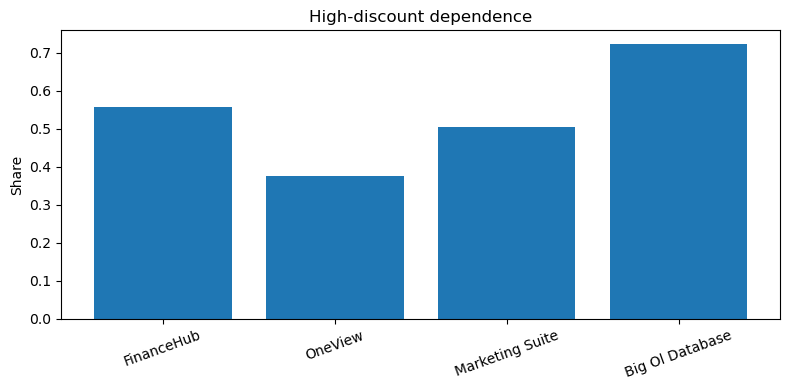

In [18]:
# 고할인 의존성
high_disc_share = []
for p in products:
    one = df[df["Product"] == p]

    total_orders = one["Order ID"].nunique()
    high_orders = one[one["Discount"] >= 0.20]["Order ID"].nunique()

    share = 0
    if total_orders > 0:
        share = high_orders / total_orders

    high_disc_share.append(share)

plt.figure(figsize=(8,4))
plt.bar(products, high_disc_share)
plt.title("High-discount dependence")
plt.ylabel("Share")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

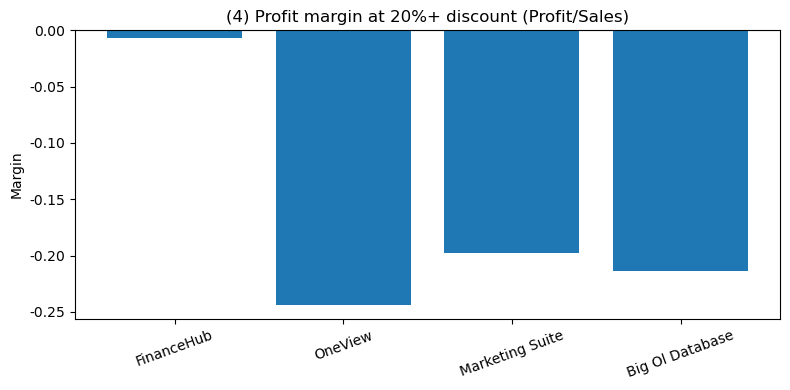

In [19]:
# 고할인 구간 마진율
high_disc_margin = []
for p in products:
    one = df[(df["Product"] == p) & (df["Discount"] >= 0.20)]

    total_sales = one["Sales"].sum()
    total_profit = one["Profit"].sum()

    margin = 0
    if total_sales != 0:
        margin = total_profit / total_sales

    high_disc_margin.append(margin)

plt.figure(figsize=(8,4))
plt.bar(products, high_disc_margin)
plt.title("(4) Profit margin at 20%+ discount (Profit/Sales)")
plt.ylabel("Margin")
plt.xticks(rotation=20)
plt.axhline(0)  # 0 기준선
plt.tight_layout()
plt.show()

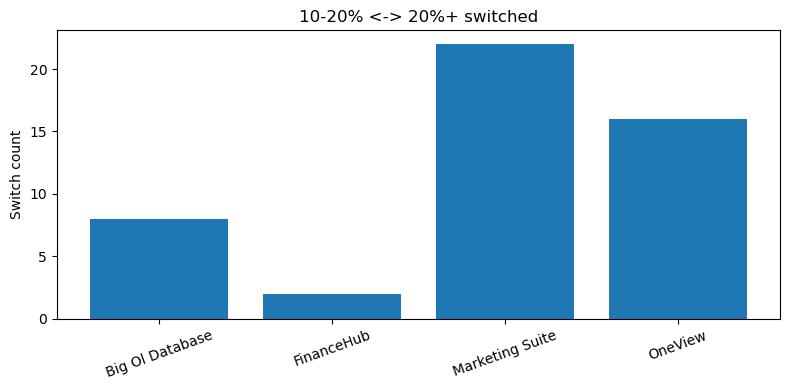

In [20]:
# 할인율 변곡횟수 그래프
pm = df[df["Product"].isin(products)].groupby(["Product","month"])["Discount"].mean().reset_index()
pm = pm.sort_values(["Product","month"])

def state(x):
    if 0.10 <= x < 0.20:
        return "10s"
    if x >= 0.20:
        return "20s"
    return "other"

pm["state"] = pm["Discount"].apply(state)

pm = pm[pm["state"].isin(["10s","20s"])]

pm["prev_state"] = pm.groupby("Product")["state"].shift(1)
pm["changed"] = (pm["state"] != pm["prev_state"]) & (pm["prev_state"].notna())

turns = pm.groupby("Product")["changed"].sum()

plt.figure(figsize=(8,4))
plt.bar(turns.index, turns.values)
plt.title("10-20% <-> 20%+ switched")
plt.ylabel("Switch count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

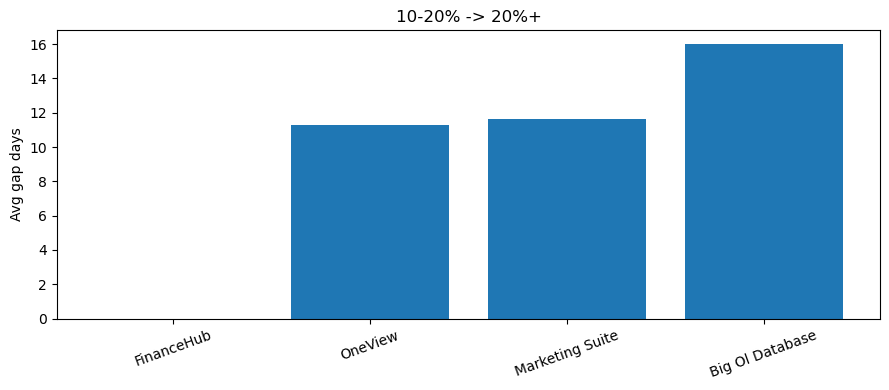

In [21]:
pm = df[df["Product"].isin(products)].groupby(["Product","month"])["Discount"].mean().reset_index()
pm = pm.sort_values(["Product","month"])

pm["state"] = "other"
pm.loc[(pm["Discount"] >= 0.10) & (pm["Discount"] < 0.20), "state"] = "10s"
pm.loc[(pm["Discount"] >= 0.20), "state"] = "20s"

avg_list = []

for p in products:
    one_pm = pm[pm["Product"] == p].sort_values("month")
    gaps = []

    for i in range(1, len(one_pm)):
        prev_state = one_pm.iloc[i-1]["state"]
        curr_state = one_pm.iloc[i]["state"]

        if (prev_state == "10s") and (curr_state == "20s"):
            prev_month = one_pm.iloc[i-1]["month"]
            curr_month = one_pm.iloc[i]["month"]

            prev_rows = df[(df["Product"] == p) & (df["month"] == prev_month)]
            curr_rows = df[(df["Product"] == p) & (df["month"] == curr_month)]

            last_prev = prev_rows["Order Date"].max()
            first_curr = curr_rows["Order Date"].min()

            if pd.notna(last_prev) and pd.notna(first_curr):
                gap_days = (first_curr.date() - last_prev.date()).days
                gaps.append(gap_days)

    if len(gaps) == 0:
        avg_gap = 0  
    else:
        avg_gap = sum(gaps) / len(gaps)

    avg_list.append(avg_gap)

plt.figure(figsize=(9,4))
plt.bar(products, avg_list)
plt.title("10-20% -> 20%+")
plt.ylabel("Avg gap days")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

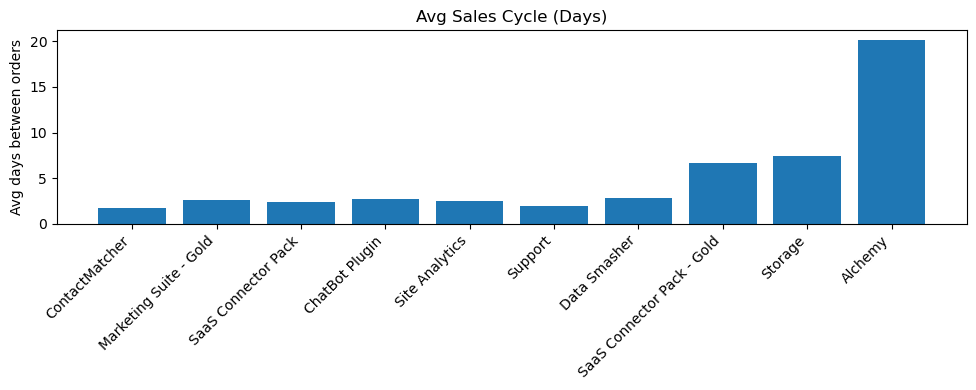

In [22]:
d = df[~df["Product"].isin(products)].copy()

names = []
avg_days = []

for p in d["Product"].unique():
    one = d[d["Product"] == p].sort_values("Order Date")

    dates = one["Order Date"].drop_duplicates()
    gaps = dates.diff().dt.days.dropna()

    if len(gaps) == 0:
        continue

    names.append(p)
    avg_days.append(gaps.mean())

cycle = pd.DataFrame({"Product": names, "avg_days_between_orders": avg_days})


plt.figure(figsize=(10,4))
plt.bar(cycle["Product"], cycle["avg_days_between_orders"])
plt.title("Avg Sales Cycle (Days)")
plt.ylabel("Avg days between orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

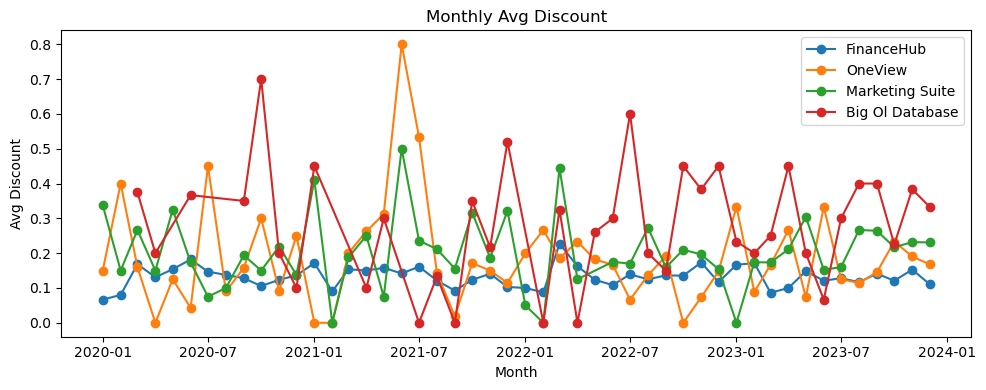

In [23]:
plt.figure(figsize=(10,4))

for p in products:
    one = pm[pm["Product"] == p]
    plt.plot(one["month"], one["Discount"], marker="o", label=p)

plt.title("Monthly Avg Discount")
plt.ylabel("Avg Discount")
plt.xlabel("Month")
plt.legend()
plt.tight_layout()
plt.show()

## 데이터 전처리

In [24]:
# 월 패널 만들기
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df = df[df["Order Date"].notna()].copy()
df["month"] = df["Order Date"].dt.to_period("M").dt.to_timestamp()

panel = df.groupby(["Product","month"], as_index=False).agg(
    orders=("Order ID","nunique"),
    sales=("Sales","sum"),
    profit=("Profit","sum"),
    avg_disc=("Discount","mean")
)

panel = panel.sort_values(["Product","month"]).copy()

- 할인율을 바꿨을 때 주문건수를 월 단위로 비교하기 위한 테이블 생성

In [25]:
# 제품별 원가 추정
tmp = panel[panel["orders"] > 0].copy()

tmp["sales_per_order"] = tmp["sales"] / tmp["orders"]
tmp["cost_per_order"] = (tmp["sales"] - tmp["profit"]) / tmp["orders"]

tmp["list_sales_per_order"] = tmp["sales_per_order"] / (1 - tmp["avg_disc"].clip(0,0.95))

prod_price = tmp.groupby("Product", as_index=False).agg(
    list_sales_per_order=("list_sales_per_order","median"),
    cost_per_order=("cost_per_order","median")
)

prod_price.head()

,Product,list_sales_per_order,cost_per_order
0,Alchemy,1799.970000,1019.979600
1,Big Ol Database,1670.315532,1100.799567
2,ChatBot Plugin,37.837356,25.814999
3,ContactMatcher,360.264013,234.016916
4,Data Smasher,225.104257,155.820175


- 할인율을 바꿨을 때 주문 1건당 가격(정가 기준)과 원가를 기준으로 매출·이익이 어떻게 달라지는지 계산하기 위해 할인 전 주문 1건당 매출(list_sales_per_order)과 주문 1건당 원가(cost_per_order)의 중간값을 확인.

In [26]:
# 수요모델용 피처 만들기
panel["orders_lag1"] = panel.groupby("Product")["orders"].shift(1)
panel["orders_lag2"] = panel.groupby("Product")["orders"].shift(2)
panel["orders_lag3"] = panel.groupby("Product")["orders"].shift(3)

panel["orders_roll3"] = (
    panel.groupby("Product")["orders"].shift(1).rolling(3).mean()
    .reset_index(level=0, drop=True)
)

panel["month_num"] = panel["month"].dt.month

- 과거 3개월간 주문 흐름 피처 생성
- 기업의 예산책정으로 월별 패턴이 생길 수 있으므로 월별 특성을 추가함

In [41]:
# 학습 데이터셋 만들기
import numpy as np
need = ["avg_disc","orders_lag1","orders_lag2","orders_lag3","orders_roll3","month_num"]
train_df = panel.dropna(subset=need).copy()

train_df["y_log_orders"] = np.log1p(train_df["orders"])

print(train_df.shape)

(602, 12)


- log1p를 사용해 주문건수의 급작스러운 변화를 줄이고, 주문건수가 음수가 되는 것을 줄임.

In [42]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# train_df에는 month, orders, y_log_orders가 있어야 함
cut = train_df["month"].max() - pd.DateOffset(months=6)

tr = train_df[train_df["month"] < cut].copy()
te = train_df[train_df["month"] >= cut].copy()

print("train rows:", tr.shape[0])
print("test rows :", te.shape[0])
print("test months:", te["month"].min(), "~", te["month"].max())

train rows: 505
test rows : 97
test months: 2023-06-01 00:00:00 ~ 2023-12-01 00:00:00


## 예측 모델링

In [43]:
# # 단순 예측 모델 예측과 비교하기 위한 값
# # 지난 3개월의 평균이 곧 미래 예측의 기준선을 잡음.
# base = train_df.sort_values(["Product","month"]).copy()
# base["pred_lag1"] = base.groupby("Product")["orders"].shift(1)

# cut = train_df["month"].max() - pd.DateOffset(months=6)
# te_base = base[base["month"] >= cut].dropna(subset=["pred_lag1"]).copy()

# y_true = te_base["orders"].values
# y_pred = te_base["pred_lag1"].values

# smape = np.mean(2*np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-9)) * 100
# print("Base sMAPE:", smape)

In [44]:
# # RandomForest 모델
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.pipeline import Pipeline
# from sklearn.ensemble import RandomForestRegressor

# X_cols = ["Product","avg_disc","orders_lag1","orders_lag2","orders_lag3","orders_roll3","month_num"]
# X_tr = tr[X_cols]
# y_tr = tr["y_log_orders"]

# X_te = te[X_cols]
# y_te_true = te["orders"].values

# pre = ColumnTransformer(
#     transformers=[
#         ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["Product"]),
#         ("num", "passthrough", ["avg_disc","orders_lag1","orders_lag2","orders_lag3","orders_roll3","month_num"])
#     ]
# )

# model = RandomForestRegressor(n_estimators=300, random_state=2026)

# pipe = Pipeline([("pre", pre), ("model", model)])
# pipe.fit(X_tr, y_tr)

- 제품별을 원-핫 인코딩해서 모델이 구분하게 함.
- 할인율과 주문수(Orders)의 관계가 선형으로 움직이지 않아 비선형 패턴을 잘 잡는 RandomForest모델을 우선 사용.

In [45]:
# # 3) 예측(log 스케일) -> orders로 되돌리기
# pred_log = pipe.predict(X_te)
# pred_orders = np.expm1(pred_log)
# pred_orders[pred_orders < 0] = 0

# # 4) 지표 계산
# mae = mean_absolute_error(y_te_true, pred_orders)
# rmse = np.sqrt(mean_squared_error(y_te_true, pred_orders))
# smape = np.mean(2*np.abs(y_te_true - pred_orders) / (np.abs(y_te_true) + np.abs(pred_orders) + 1e-9)) * 100

# print("RandomForest모델")
# print("MAE :", mae)
# print("RMSE:", rmse)
# print("sMAPE(%):", smape)

In [46]:
# HGB 모델
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor

X_cols = ["Product","avg_disc","orders_lag1","orders_lag2","orders_lag3","orders_roll3","month_num"]
X_tr = tr[X_cols]
y_tr = tr["y_log_orders"]

X_te = te[X_cols]
y_te_true = te["orders"].values

pre = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["Product"]),
        ("num", "passthrough", ["avg_disc","orders_lag1","orders_lag2","orders_lag3","orders_roll3","month_num"])
    ]
)

model = HistGradientBoostingRegressor(random_state=2026)

pipe = Pipeline([("pre", pre), ("model", model)])
pipe.fit(X_tr, y_tr)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Product']),
                                                 ('num', 'passthrough',
                                                  ['avg_disc', 'orders_lag1',
                                                   'orders_lag2', 'orders_lag3',
                                                   'orders_roll3',
                                                   'month_num'])])),
                ('model', HistGradientBoostingRegressor(random_state=2026))])

In [47]:
# 3) 예측(log 스케일) -> orders로 되돌리기
pred_log = pipe.predict(X_te)
pred_orders = np.expm1(pred_log)
pred_orders[pred_orders < 0] = 0

# 4) 지표 계산
mae = mean_absolute_error(y_te_true, pred_orders)
rmse = np.sqrt(mean_squared_error(y_te_true, pred_orders))
smape = np.mean(2*np.abs(y_te_true - pred_orders) / (np.abs(y_te_true) + np.abs(pred_orders) + 1e-9)) * 100

print("HGB모델")
print("MAE :", mae)
print("RMSE:", rmse)
print("sMAPE(%):", smape)

HGB모델
MAE : 4.557132828172999
RMSE: 7.0625021435501445
sMAPE(%): 25.241707024024247


In [ ]:
# from sklearn.pipeline import Pipeline
# from sklearn.linear_model import PoissonRegressor

# X_tr = tr[X_cols]
# y_tr = tr["orders"]       
# X_te = te[X_cols]
# y_te_true = te["orders"].values

# model = PoissonRegressor(alpha=1e-6, max_iter=3000)

# pipe = Pipeline([("pre", pre), ("model", model)])
# pipe.fit(X_tr, y_tr)

# pred_orders = pipe.predict(X_te)
# pred_orders[pred_orders < 0] = 0

In [ ]:
# mae = mean_absolute_error(y_te_true, pred_orders)
# rmse = np.sqrt(mean_squared_error(y_te_true, pred_orders))
# smape = np.mean(2*np.abs(y_te_true - pred_orders) / (np.abs(y_te_true) + np.abs(pred_orders) + 1e-9)) * 100

# print("Poisson모델")
# print("MAE :", mae)
# print("RMSE:", rmse)
# print("sMAPE(%):", smape)

In [68]:
# 할인율 생성(모든 수)
cands = list(np.round(np.arange(0.00, 0.35 + 0.01, 0.01), 2))
print("cand count:", len(cands))
print("sample:", cands[:20], "...", cands[-5:])

cand count: 36
sample: [np.float64(0.0), np.float64(0.01), np.float64(0.02), np.float64(0.03), np.float64(0.04), np.float64(0.05), np.float64(0.06), np.float64(0.07), np.float64(0.08), np.float64(0.09), np.float64(0.1), np.float64(0.11), np.float64(0.12), np.float64(0.13), np.float64(0.14), np.float64(0.15), np.float64(0.16), np.float64(0.17), np.float64(0.18), np.float64(0.19)] ... [np.float64(0.31), np.float64(0.32), np.float64(0.33), np.float64(0.34), np.float64(0.35)]


- 어떤 할인율에서 가장 높은 매출을 발생시키는지 확인하기 위해 0~35%의 할인율 범위에서 할인율 생성

In [69]:
# 할인율이 20% 이상인 달 데이터 만들기
cap = 0.20
hi = train_df[train_df["avg_disc"] >= cap].copy()
print("high-discount rows:", hi.shape)

high-discount rows: (139, 12)


In [70]:
# 할인율이 20%이상인 달만 대상으로 제품별 최적 할인율 계산
best_rows = []

# 해당 제품의 가격/원가 가져오기
for p in hi["Product"].unique():
    one = hi[hi["Product"] == p].copy()
    price = prod_price[prod_price["Product"] == p]

    if len(price) == 0:
        continue

    list_sale = float(price["list_sales_per_order"].values[0])
    cost = float(price["cost_per_order"].values[0])

    # 최적 할인율 저장할 변수 초기화, 이익은 최소값으로 초기화
    best_d = None
    best_profit = -1e18
    best_sales = None
    best_orders = None

    # 후보 할인율 반복 대입 계산
    for d in cands:
        # 이익이 무조건 음수인 할인율이면 스킵
        profit_per_order = (list_sale * (1 - d)) - cost
        if profit_per_order < 0:
            continue

        # 할인율 d일 때 주문건수 예측
        X_try = one[X_cols].copy()
        X_try["avg_disc"] = d

        pred_log = pipe.predict(X_try)
        pred_orders = np.expm1(pred_log)
        pred_orders[pred_orders < 0] = 0

        # 할인율 d일 때 매출, 이익 계산
        sales_per_order = list_sale * (1 - d)

        pred_sales = (pred_orders * sales_per_order).sum()
        pred_profit = (pred_orders * profit_per_order).sum()
        pred_order_sum = pred_orders.sum()

        # 이익이 최대면 할인율 값 업데이트
        if pred_profit > best_profit:
            best_profit = pred_profit
            best_d = d
            best_sales = pred_sales
            best_orders = pred_order_sum

    # 만약 Profit>=0 되는 d가 하나도 없으면 손실이 가장 덜 나는 할인율 선택
    if best_d is None:
        best_d = None
        best_profit = -1e18
        best_sales = None
        best_orders = None

        for d in cands:
            profit_per_order = (list_sale * (1 - d)) - cost

            X_try = one[X_cols].copy()
            X_try["avg_disc"] = d

            pred_log = pipe.predict(X_try)
            pred_orders = np.expm1(pred_log)
            pred_orders[pred_orders < 0] = 0

            sales_per_order = list_sale * (1 - d)

            pred_sales = (pred_orders * sales_per_order).sum()
            pred_profit = (pred_orders * profit_per_order).sum()
            pred_order_sum = pred_orders.sum()

            if pred_profit > best_profit:
                best_profit = pred_profit
                best_d = d
                best_sales = pred_sales
                best_orders = pred_order_sum

    best_rows.append([p, best_d, best_orders, best_sales, best_profit])

# 결과 테이블
best = pd.DataFrame(best_rows, columns=["Product","best_discount","pred_orders_hi","pred_sales_hi","pred_profit_hi"])
best = best.sort_values("pred_profit_hi", ascending=False)
best.head(10)

,Product,best_discount,pred_orders_hi,pred_sales_hi,pred_profit_hi
2,ContactMatcher,0.01,1407.515052,502006.251263,172623.919906
1,Big Ol Database,0.01,108.870475,180029.564536,60184.993080
0,Alchemy,0.01,55.819719,99469.081589,42534.106830
5,Marketing Suite,0.01,108.198084,63129.044763,13819.755936
6,OneView,0.01,145.035668,33216.840549,9308.145162
9,Site Analytics,0.01,72.075138,31482.193490,8023.486868
7,SaaS Connector Pack,0.01,71.943607,7704.534346,1976.666636
4,FinanceHub,0.01,18.075419,7613.325614,1689.751227
8,SaaS Connector Pack - Gold,0.01,25.485387,1779.155624,791.963848
3,Data Smasher,0.01,8.440016,1880.884679,565.759921


In [71]:
# 데이터에서 20% 이상 할인율 적용한 제품들의 손실 vs 최적 할인율 적용시 예측 주문건수, 매출, 순이익 변화
actual_hi = hi.groupby("Product", as_index=False).agg(
    actual_orders_hi=("orders","sum"),
    actual_sales_hi=("sales","sum"),
    actual_profit_hi=("profit","sum")
)

cmp = actual_hi.merge(best, on="Product", how="inner")
cmp["orders_change_pct"] = (cmp["pred_orders_hi"] / cmp["actual_orders_hi"] - 1) * 100
cmp["sales_change_pct"]  = (cmp["pred_sales_hi"]  / cmp["actual_sales_hi"]  - 1) * 100
cmp["profit_change"] = cmp["pred_profit_hi"] - cmp["actual_profit_hi"]

cmp = cmp.sort_values("actual_sales_hi", ascending=False)
cmp.head(10)

,Product,actual_orders_hi,actual_sales_hi,actual_profit_hi,best_discount,pred_orders_hi,pred_sales_hi,pred_profit_hi,orders_change_pct,sales_change_pct,profit_change
2,ContactMatcher,1507,399435.3600,13183.8545,0.01,1407.515052,502006.251263,172623.919906,-6.601523,25.678971,159440.065406
1,Big Ol Database,89,125273.4200,-7634.7288,0.01,108.870475,180029.564536,60184.993080,22.326376,43.709308,67819.721880
0,Alchemy,27,61639.2720,18760.8010,0.01,55.819719,99469.081589,42534.106830,106.739700,61.372901,23773.305830
5,Marketing Suite,106,45982.0681,-4586.2919,0.01,108.198084,63129.044763,13819.755936,2.073665,37.290573,18406.047836
9,Site Analytics,66,24443.6600,1913.3860,0.01,72.075138,31482.193490,8023.486868,9.204754,28.794925,6110.100868
6,OneView,102,22652.1300,1551.6827,0.01,145.035668,33216.840549,9308.145162,42.191831,46.638928,7756.462462
4,FinanceHub,11,5703.1220,4.8678,0.01,18.075419,7613.325614,1689.751227,64.321995,33.493999,1684.883427
7,SaaS Connector Pack,61,5510.6320,-153.3243,0.01,71.943607,7704.534346,1976.666636,17.940339,39.812173,2129.990936
8,SaaS Connector Pack - Gold,10,694.2160,236.1655,0.01,25.485387,1779.155624,791.963848,154.853875,156.282717,555.798348
3,Data Smasher,3,498.3680,91.3458,0.01,8.440016,1880.884679,565.759921,181.333864,277.408798,474.414121


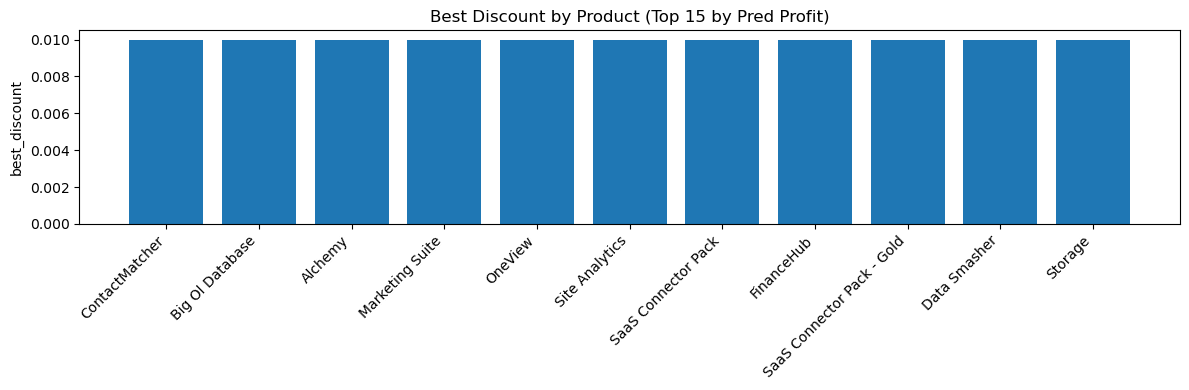

In [72]:
top = best.sort_values("pred_profit_hi", ascending=False).head(15).sort_values("best_discount")
plt.figure(figsize=(12,4))
plt.bar(top["Product"], top["best_discount"])
plt.title("Best Discount by Product (Top 15 by Pred Profit)")
plt.ylabel("best_discount")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

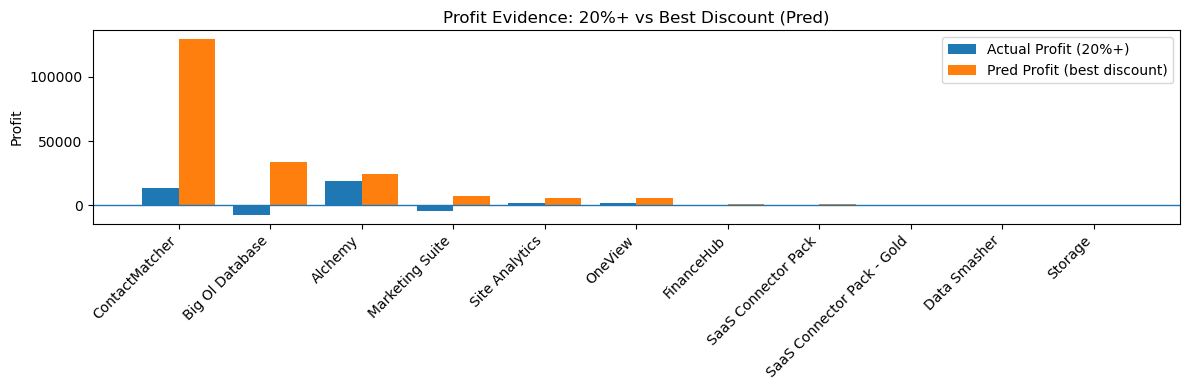

In [63]:
# 제품별 순이익 비교
topN = 14
show = cmp.head(topN)

x = np.arange(len(show))
w = 0.4

plt.figure(figsize=(12,4))
plt.bar(x - w/2, show["actual_profit_hi"], width=w, label="Actual Profit (20%+)")
plt.bar(x + w/2, show["pred_profit_hi"], width=w, label="Pred Profit (best discount)")

plt.xticks(x, show["Product"], rotation=45, ha="right")
plt.axhline(0, linewidth=1)
plt.title("Profit Evidence: 20%+ vs Best Discount (Pred)")
plt.ylabel("Profit")
plt.legend()
plt.tight_layout()
plt.show()

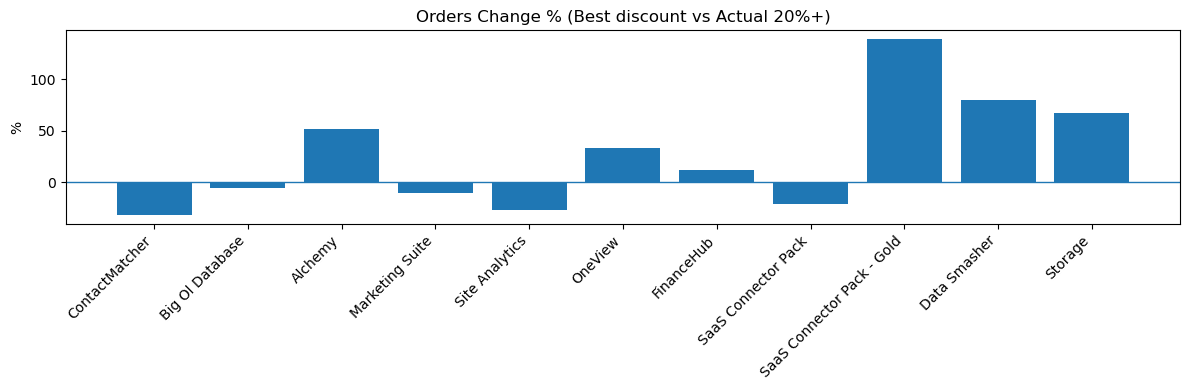

In [64]:
# 제품별 주문건수 비교
plt.figure(figsize=(12,4))
plt.bar(show["Product"], show["orders_change_pct"])
plt.axhline(0, linewidth=1)
plt.title("Orders Change % (Best discount vs Actual 20%+)")
plt.ylabel("%")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

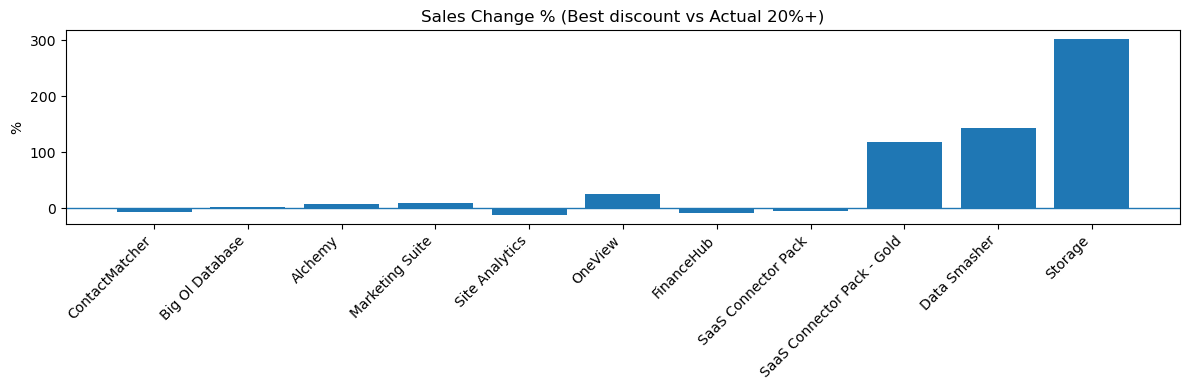

In [65]:
# 제품별 매출 비교
plt.figure(figsize=(12,4))
plt.bar(show["Product"], show["sales_change_pct"])
plt.axhline(0, linewidth=1)
plt.title("Sales Change % (Best discount vs Actual 20%+)")
plt.ylabel("%")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

=== TOTAL (20%+ segment only) ===
Actual Orders: 1986  / Pred Orders: 1527.5943009310013  / change%: -23.081857959164086
Actual Sales : 691853.1121  / Pred Sales : 676243.4280675581  / change%: -2.256213603645063
Actual Profit: 23371.433899999996  / Pred Profit: 210217.2491914809  / change : 186845.8152914809


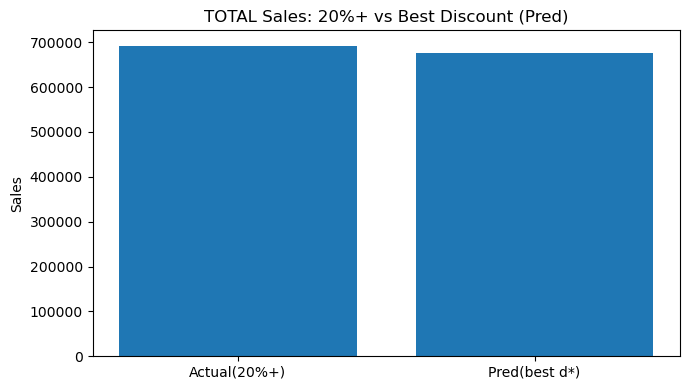

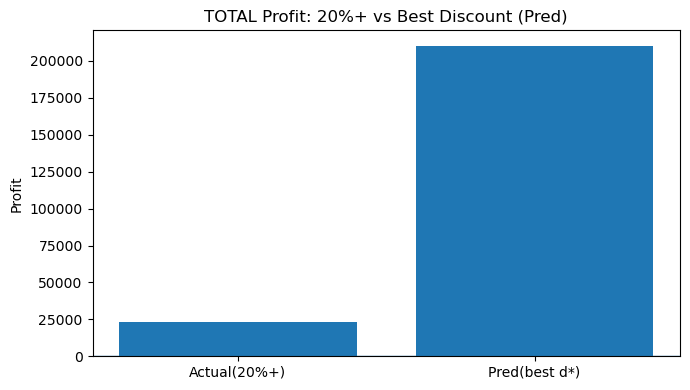

In [66]:
# kpi 비교 시각화
a_orders = cmp["actual_orders_hi"].sum()
a_sales  = cmp["actual_sales_hi"].sum()
a_profit = cmp["actual_profit_hi"].sum()

p_orders = cmp["pred_orders_hi"].sum()
p_sales  = cmp["pred_sales_hi"].sum()
p_profit = cmp["pred_profit_hi"].sum()

print("=== TOTAL (20%+ segment only) ===")
print("Actual Orders:", a_orders, " / Pred Orders:", p_orders, " / change%:", (p_orders/a_orders-1)*100)
print("Actual Sales :", a_sales,  " / Pred Sales :", p_sales,  " / change%:", (p_sales/a_sales-1)*100)
print("Actual Profit:", a_profit, " / Pred Profit:", p_profit, " / change :", (p_profit-a_profit))

labels = ["Actual(20%+)", "Pred(best d*)"]
vals_sales = [a_sales, p_sales]
vals_profit = [a_profit, p_profit]

plt.figure(figsize=(7,4))
plt.bar(labels, vals_sales)
plt.title("TOTAL Sales: 20%+ vs Best Discount (Pred)")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.bar(labels, vals_profit)
plt.axhline(0, linewidth=1)
plt.title("TOTAL Profit: 20%+ vs Best Discount (Pred)")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()